We first import the libraries required for data manipulation, visualization, preprocessing, clustering, regression, and model evaluation. This allows us to perform the complete analytics workflow from data cleaning to predictive modelling.



In [ ]:
from datetime import date
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import cross_val_score, KFold

We load the Nata Supermarkets marketing dataset into a Pandas DataFrame. The marketing sheet contains customer demographic, purchasing, promotional, and behavioural information that will be used for our analysis.

In [ ]:
df = pd.read_excel('/content/nata_supermarket_data.xlsx', sheet_name = 'marketing')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-04-09 00:00:00,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-08-03 00:00:00,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-10-02 00:00:00,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

We use info() to understand the structure of the dataset, including the number of observations, variables, data types, and presence of missing values. This helps us identify variables that require preprocessing before analysis.

ID is converted to a string because it is an identifier and should not be treated as a numerical variable.
Dt_Customer is converted into a datetime format so that we can perform date-based calculations later.

In [ ]:
df['ID'] = df['ID'].astype(str)

df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])

The last three columns are removed because they are not required for our analytical objective. Removing irrelevant variables helps avoid unnecessary noise in the modelling process.

In [ ]:
df = df.drop(df.columns[-3:], axis = 1)

df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain
0,5524,1957,Graduation,Single,58138.0,0,0,2012-04-09,58,635,...,8,10,4,7,0,0,0,0,0,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-08-03,38,11,...,1,1,2,5,0,0,0,0,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,0,0,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-10-02,26,11,...,2,0,4,6,0,0,0,0,0,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,...,9,3,4,5,0,0,0,0,0,0
2236,4001,1946,PhD,Together,64014.0,2,1,2014-10-06,56,406,...,8,2,5,7,0,0,0,1,0,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,...,2,3,13,6,0,1,0,0,0,0
2238,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,...,6,5,10,3,0,0,0,0,0,0


We examine summary statistics such as mean, standard deviation, minimum, maximum, and quartiles. This helps us identify unusual values and understand the distribution of important numerical variables.

In [ ]:
df.describe()

,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain
count,2240.000000,2216.000000,2240.000000,2240.000000,2240,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,1968.805804,52247.251354,0.444196,0.506250,2013-07-11 22:57:38.571428608,49.109375,303.935714,26.302232,166.950000,37.525446,...,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375
min,1893.000000,1730.000000,0.000000,0.000000,2012-01-08 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1959.000000,35303.000000,0.000000,0.000000,2013-01-19 18:00:00,24.000000,23.750000,1.000000,16.000000,3.000000,...,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1970.000000,51381.500000,0.000000,0.000000,2013-07-11 00:00:00,49.000000,173.500000,8.000000,67.000000,12.000000,...,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1977.000000,68522.000000,1.000000,1.000000,2013-12-30 06:00:00,74.000000,504.250000,33.000000,232.000000,50.000000,...,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1996.000000,666666.000000,2.000000,2.000000,2014-12-06 00:00:00,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
std,11.984069,25173.076661,0.538398,0.544538,NaN,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391


We visualise the distribution of Year_Birth to identify unusual or potentially erroneous observations. Extremely low birth years can represent data-entry errors and can distort age-related analysis.

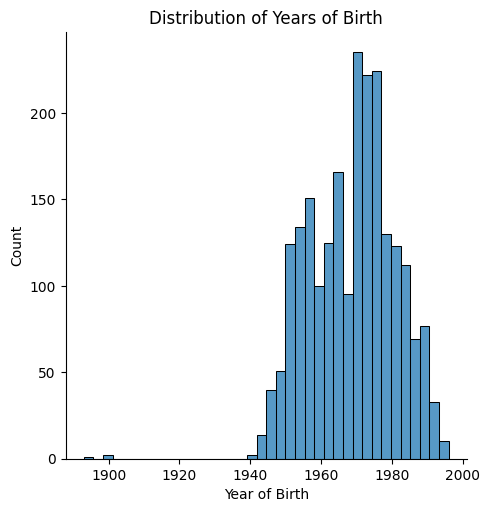

In [ ]:
# Distribution of Year_Birth
sns.displot(data = df, x = 'Year_Birth')

# Add labels
plt.title('Distribution of Years of Birth')
plt.xlabel('Year of Birth')
plt.ylabel('Count')

plt.show()

Removing Implausible Birth-Year Observations

Based on the distribution, we retain customers with a birth year of 1940 or later. This removes implausible observations that could otherwise affect customer segmentation and demographic analysis.

In [ ]:
df = df[df['Year_Birth'] >= 1940]

Income is an important customer characteristic and may also contain extreme observations. We first visualise its distribution to understand its spread and identify potential outliers.

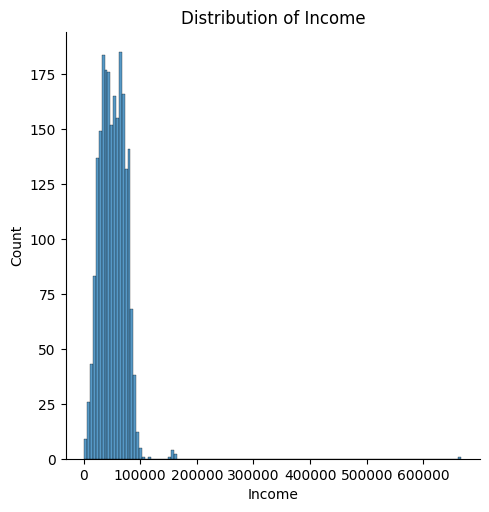

In [ ]:
sns.displot(data = df, x = 'Income')

# Add labels
plt.title('Distribution of Income')
plt.xlabel('Income')
plt.ylabel('Count')

plt.show()

A boxplot helps us visually identify extreme income observations. Since extreme values can disproportionately influence clustering and regression, we examine them before proceeding.

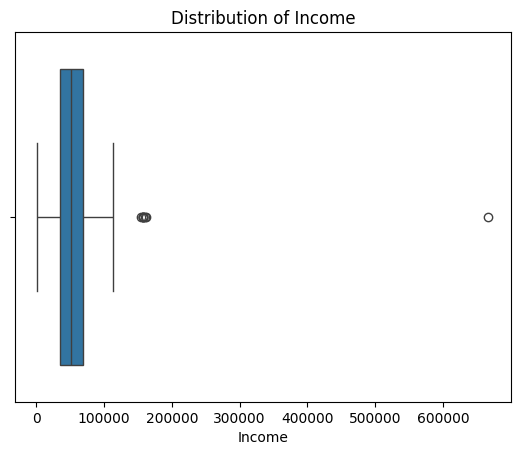

In [ ]:
# Distribution of Income
sns.boxplot(data = df, x = 'Income')

# Add labels
plt.title('Distribution of Income')

plt.show()

IQR-Based Outlier Treatment

We use the Interquartile Range (IQR) method to identify unusually high income observations.
The upper threshold is calculated as:

Upper Bound = Q3 + 1.5 × IQR

Observations above this threshold are excluded so that extreme income values do not disproportionately influence the analysis.

After removing the identified income outliers, we visualise the distribution again to verify that the extreme observations have been addressed and that the remaining data has a more suitable distribution for analysis.

In [ ]:
income_q1 = df['Income'].quantile(.25)
income_q3 = df['Income'].quantile(.75)
income_iqr = income_q3 - income_q1
income_upper = income_q3 + 1.5 * income_iqr

# Remove outliers from income
df = df[df['Income'] <= income_upper]

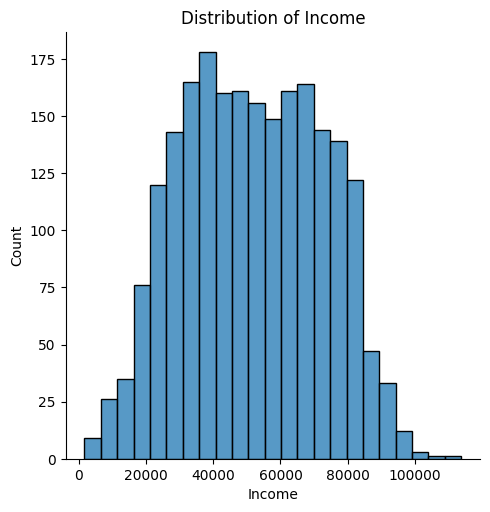

In [ ]:
sns.displot(data = df, x = 'Income')

# Add labels
plt.title('Distribution of Income')
plt.xlabel('Income')
plt.ylabel('Count')

plt.show()

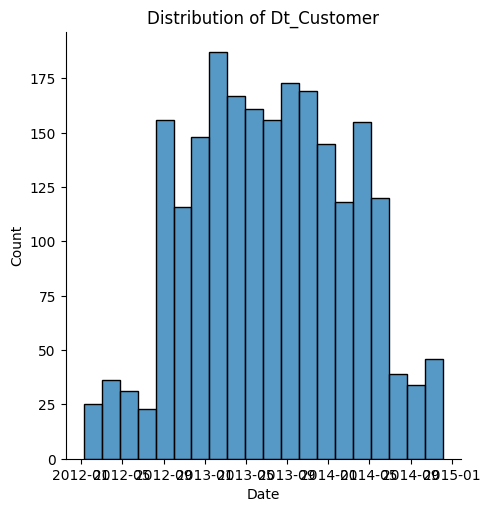

In [ ]:
# Distribution of Dt_Customer
sns.displot(data = df, x = 'Dt_Customer')

# Add labels
plt.title('Distribution of Dt_Customer')
plt.xlabel('Date')
plt.ylabel('Count')

plt.show()

We check each variable for missing observations. Missing values can affect statistical analysis and machine-learning algorithms, so we verify the data quality before proceeding.

In [ ]:
# Check for nulls
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2205 entries, 0 to 2239
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2205 non-null   object        
 1   Year_Birth           2205 non-null   int64         
 2   Education            2205 non-null   object        
 3   Marital_Status       2205 non-null   object        
 4   Income               2205 non-null   float64       
 5   Kidhome              2205 non-null   int64         
 6   Teenhome             2205 non-null   int64         
 7   Dt_Customer          2205 non-null   datetime64[ns]
 8   Recency              2205 non-null   int64         
 9   MntWines             2205 non-null   int64         
 10  MntFruits            2205 non-null   int64         
 11  MntMeatProducts      2205 non-null   int64         
 12  MntFishProducts      2205 non-null   int64         
 13  MntSweetProducts     2205 non-null   i

We examine the frequency distribution of education and marital status to understand the composition of our customer base and identify categories that may require consolidation.

In [ ]:
# Get counts by Education
subset_education = df.groupby('Education')['ID'].count().reset_index()
subset_education

,Education,ID
0,2n Cycle,198
1,Basic,54
2,Graduation,1113
3,Master,364
4,PhD,476


Consolidating Rare Marital-Status Categories

The categories Absurd, Alone, and YOLO have very small frequencies and are treated as Single for analytical purposes. This reduces sparse categories and makes the categorical variable more meaningful for segmentation.

In [ ]:
# Get counts by Martital_Status
subset_marital = df.groupby('Marital_Status')['ID'].count().reset_index()
subset_marital

,Marital_Status,ID
0,Absurd,2
1,Alone,3
2,Divorced,230
3,Married,854
4,Single,470
5,Together,568
6,Widow,76
7,YOLO,2


In [ ]:
# Let's assume Absurd, Alone, and YOLO are Single
df['Marital_Status'] = np.where(df['Marital_Status'].isin(['Absurd', 'Alone', 'YOLO']), 'Single', df['Marital_Status'])

Preparing the Modelling Dataset

Customer ID is removed because it is only an identifier and does not contain behavioural information useful for clustering or prediction.

In [ ]:
# Drop ID Column
df_ml = df.drop('ID', axis=1)

Converting Enrollment Date

Instead of using the actual enrollment date as a categorical date, we convert it into the number of days since the reference date, 31 December 2014. This transforms the date into a numerical measure representing customer tenure.

In [ ]:
# Covert DT_Customer to days since enrollment
date_reference = pd.to_datetime('2014-12-31') # Assuming the last day of the year from when the data was collected
df_ml['Dt_Customer'] = date_reference - df_ml['Dt_Customer']
df_ml['Dt_Customer'] = abs(df_ml['Dt_Customer'].dt.days.astype(int))

df_ml['Dt_Customer'].info()

<class 'pandas.core.series.Series'>
Index: 2205 entries, 0 to 2239
Series name: Dt_Customer
Non-Null Count  Dtype
--------------  -----
2205 non-null   int64
dtypes: int64(1)
memory usage: 34.5 KB


K-Means clustering is distance-based. Therefore, variables measured on different scales can disproportionately influence the clustering result. We standardise the appropriate numerical variables so that variables are comparable in scale.

In [ ]:
# Identify columns to standardize and columns to exclude
# Exclude ID, categorical, and binary columns from standardization
columns_to_exclude = ['Education', 'Marital_Status', 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Complain']
columns_to_standardize = [col for col in df_ml.columns if col not in columns_to_exclude]

# Separate the DataFrame
df_to_standardize = df_ml[columns_to_standardize]
df_excluded = df_ml[columns_to_exclude]

# Initialize and apply StandardScaler to the columns to standardize
scaler = StandardScaler()
df_standardized = scaler.fit_transform(df_to_standardize)

# Convert the standardized numpy array back to a DataFrame
df_standardized = pd.DataFrame(df_standardized, columns=columns_to_standardize, index=df_ml.index)

# Concatenate the standardized and excluded columns
df_ml_scaled = pd.concat([df_standardized, df_excluded], axis=1)

One-Hot Encoding

K-Means requires numerical inputs. Therefore, categorical variables such as Education and Marital Status are converted into binary dummy variables using one-hot encoding.

In [ ]:
# One-hot encoding for categorical variables
df_ml_scaled = pd.get_dummies(df_ml_scaled, columns = ['Education', 'Marital_Status'], dtype = int)

Determining the Number of Clusters

We use the Elbow Method to determine an appropriate number of customer segments. For different values of K, we calculate the Sum of Squared Errors (SSE), also called inertia.

In [ ]:
sse = []
k_range = range(1, 10)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=206)
    kmeans.fit(df_ml_scaled)
    sse.append(kmeans.inertia_)

Elbow Method

The elbow point represents a value of K beyond which adding additional clusters provides relatively smaller improvements in SSE. Based on the elbow plot, we select 3 clusters for customer segmentation.


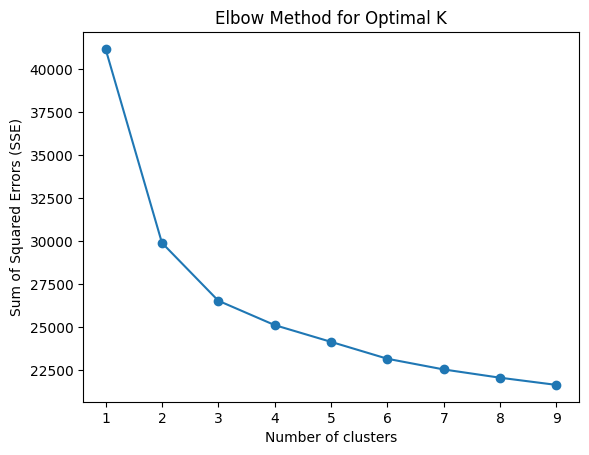

In [ ]:
plt.plot(k_range, sse, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.show()

Customer Segmentation Using K-Means

We apply K-Means clustering with three clusters. The algorithm groups customers such that customers within a cluster are relatively similar to each other based on the selected demographic and behavioural variables.

In [ ]:
# Set the optimal number of clusters based on the elbow method
optimal_k = 3

# Create and fit the K-Means model
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=206,
    n_init=10
)

# Assign cluster labels to each observation
df_ml['cluster'] = kmeans.fit_predict(df_ml_scaled)

# Convert categorical variables into dummy variables
df_ml = pd.get_dummies(
    df_ml,
    columns=['Education', 'Marital_Status'],
    dtype=int
)

Profiling the Customer Segments

After assigning customers to clusters, we calculate the mean values of the variables within each cluster. This allows us to understand the characteristics of each customer segment in terms of income, household characteristics, purchasing behaviour, and other variables.

In [ ]:
# Analyze Characteristics of Clusters
cluster_means = df_ml.groupby('cluster').mean().round(2)
cluster_means

,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow
cluster,,,,,,,,,,,,,,,,,,,,,
0,1964.30,57596.84,0.23,0.94,593.43,48.00,461.40,20.16,131.91,28.33,...,0.06,0.00,0.48,0.19,0.27,0.12,0.41,0.16,0.27,0.04
1,1968.35,75305.78,0.05,0.18,535.31,49.33,598.15,69.42,442.75,99.95,...,0.09,0.00,0.56,0.14,0.20,0.10,0.36,0.25,0.25,0.04
2,1972.04,34086.00,0.80,0.43,503.74,49.44,40.24,4.97,22.91,7.02,...,0.11,0.05,0.49,0.16,0.19,0.10,0.39,0.24,0.25,0.02


Creating the Target Variable

We create total_purchases by summing spending across the six product categories: wine, fruits, meat, fish, sweets, and gold products.

This gives us a single measure of overall customer spending that can later be analysed using correlation and regression.

Avoiding Redundancy

After creating total purchases, the six individual product-spending variables are removed from the modelling dataset. Keeping both the individual components and their sum could introduce redundancy and multicollinearity in the regression model.

In [ ]:
# Create total_purchases
df_ml['total_purchases'] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']

# Drop purchase columns
df_ml = df_ml.drop(['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds'], axis=1)

df_ml

,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,...,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,total_purchases
0,1957,58138.0,0,0,996,58,3,8,10,4,...,0,1,0,0,0,0,1,0,0,1617
1,1954,46344.0,1,1,150,38,2,1,1,2,...,0,1,0,0,0,0,1,0,0,27
2,1965,71613.0,0,0,497,26,1,8,2,10,...,0,1,0,0,0,0,0,1,0,776
3,1984,26646.0,1,0,90,26,2,2,0,4,...,0,1,0,0,0,0,0,1,0,53
4,1981,58293.0,1,0,346,94,5,5,3,6,...,0,0,0,1,0,1,0,0,0,422
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,1967,61223.0,0,1,566,46,2,9,3,4,...,0,1,0,0,0,1,0,0,0,1341
2236,1946,64014.0,2,1,86,56,7,8,2,5,...,0,0,0,1,0,0,0,1,0,444
2237,1981,56981.0,0,0,340,91,1,2,3,13,...,0,1,0,0,1,0,0,0,0,1241
2238,1956,69245.0,0,1,341,8,2,6,5,10,...,0,0,1,0,0,0,0,1,0,843


Converting Cluster Labels

Cluster membership is a categorical variable. We convert it into dummy variables so that it can be incorporated into subsequent statistical modelling.

In [ ]:
# One hot encode cluster
df_ml = pd.get_dummies(df_ml, columns = ['cluster'], dtype = int)

In [ ]:
df_ml

,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,...,Education_PhD,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,total_purchases,cluster_0,cluster_1,cluster_2
0,1957,58138.0,0,0,996,58,3,8,10,4,...,0,0,0,1,0,0,1617,0,1,0
1,1954,46344.0,1,1,150,38,2,1,1,2,...,0,0,0,1,0,0,27,1,0,0
2,1965,71613.0,0,0,497,26,1,8,2,10,...,0,0,0,0,1,0,776,0,1,0
3,1984,26646.0,1,0,90,26,2,2,0,4,...,0,0,0,0,1,0,53,1,0,0
4,1981,58293.0,1,0,346,94,5,5,3,6,...,1,0,1,0,0,0,422,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,1967,61223.0,0,1,566,46,2,9,3,4,...,0,0,1,0,0,0,1341,0,0,1
2236,1946,64014.0,2,1,86,56,7,8,2,5,...,1,0,0,0,1,0,444,0,0,1
2237,1981,56981.0,0,0,340,91,1,2,3,13,...,0,1,0,0,0,0,1241,0,1,0
2238,1956,69245.0,0,1,341,8,2,6,5,10,...,0,0,0,0,1,0,843,0,0,1


Defining Predictors and Target

total_purchases is our dependent variable because we want to understand and predict overall customer spending. The remaining variables are initially considered as potential explanatory variables.

In [ ]:
# Define y variable
y = df_ml['total_purchases']

# Define x variables
X = df_ml.drop('total_purchases', axis = 1)

# Apply train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 206)

Train-Test Split

We divide the data into 80% training data and 20% testing data. The training data is used to estimate the model, while the test data is kept aside to evaluate how well the model performs on unseen observations.

In [ ]:
# Create df_train for analysis
df_train = pd.concat([X_train, y_train], axis = 1)
df_train

,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,...,Education_PhD,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,cluster_0,cluster_1,cluster_2,total_purchases
1315,1962,27238.0,1,1,620,39,3,3,0,3,...,1,0,0,1,0,0,1,0,0,57
2112,1953,34587.0,1,1,229,68,2,1,0,3,...,0,0,0,0,1,0,1,0,0,22
806,1971,56850.0,0,1,283,83,1,1,1,3,...,0,0,1,0,0,0,1,0,0,63
405,1965,48006.0,1,1,116,55,1,1,0,3,...,0,0,1,0,0,0,1,0,0,41
1599,1975,36663.0,1,0,250,40,1,1,1,3,...,1,0,1,0,0,0,1,0,0,35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2092,1976,71322.0,0,1,329,31,1,4,1,7,...,0,0,0,0,1,0,0,0,1,350
519,1944,80184.0,0,0,362,19,1,6,3,10,...,0,0,1,0,0,0,0,1,0,1902
204,1965,40637.0,1,1,532,72,2,1,0,3,...,1,0,0,1,0,0,1,0,0,38
2143,1957,23539.0,0,0,306,13,1,2,0,4,...,0,0,1,0,0,0,1,0,0,81


In [ ]:
# Reverse one-hot encoding

# Identify one-hot columns
one_hot_education = ['Education_2n Cycle', 'Education_Basic', 'Education_Graduation', 'Education_Master', 'Education_PhD']
one_hot_marital = ['Marital_Status_Divorced', 'Marital_Status_Married', 'Marital_Status_Single', 'Marital_Status_Together', 'Marital_Status_Widow']
one_hot_cluster = ['cluster_0', 'cluster_1']

# Apply
df_train['Education'] = df_train[one_hot_education].idxmax(axis=1).str.replace('Education_', '')
df_train['Marital_Status'] = df_train[one_hot_marital].idxmax(axis=1).str.replace('Marital_Status_', '')
df_train['cluster'] = df_train[one_hot_cluster].idxmax(axis=1).str.replace('cluster_', '')

# Drop one-hot columns
df_train = df_train.drop(columns = one_hot_education, axis = 1)
df_train = df_train.drop(columns = one_hot_marital, axis = 1)
df_train = df_train.drop(columns = one_hot_cluster, axis = 1)

In [ ]:
df_train

,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,cluster_2,total_purchases,Education,Marital_Status,cluster
1315,1962,27238.0,1,1,620,39,3,3,0,3,...,0,0,0,0,0,0,57,PhD,Single,0
2112,1953,34587.0,1,1,229,68,2,1,0,3,...,0,0,0,0,0,0,22,Graduation,Together,0
806,1971,56850.0,0,1,283,83,1,1,1,3,...,0,0,0,0,0,0,63,Master,Married,0
405,1965,48006.0,1,1,116,55,1,1,0,3,...,0,0,0,0,0,0,41,Graduation,Married,0
1599,1975,36663.0,1,0,250,40,1,1,1,3,...,0,0,0,0,0,0,35,PhD,Married,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2092,1976,71322.0,0,1,329,31,1,4,1,7,...,0,0,0,0,0,1,350,Graduation,Together,0
519,1944,80184.0,0,0,362,19,1,6,3,10,...,0,1,1,0,0,0,1902,Master,Married,1
204,1965,40637.0,1,1,532,72,2,1,0,3,...,0,0,0,0,0,0,38,PhD,Single,0
2143,1957,23539.0,0,0,306,13,1,2,0,4,...,0,0,0,0,0,0,81,Graduation,Married,0


Correlation Analysis

We examine the correlation between numerical variables and total purchases to identify variables that have stronger linear associations with customer spending.

Correlation indicates association, not causation. Therefore, a strong correlation does not necessarily mean that one variable causes changes in another.

In [ ]:
# Correlation Analysis
correlation_matrix = df_train.drop(['Education', 'Marital_Status', 'cluster'], axis = 1).corr().round(2)
correlation_matrix['total_purchases'].sort_values()

,total_purchases
Kidhome,-0.57
NumWebVisitsMonth,-0.50
Teenhome,-0.14
Year_Birth,-0.13
NumDealsPurchases,-0.07
Complain,-0.04
Recency,0.03
AcceptedCmp3,0.07
cluster_2,0.14
AcceptedCmp2,0.14


Checking Multicollinearity

We check for highly correlated predictor variables because strong correlation among independent variables can create multicollinearity and make regression coefficients difficult to interpret reliably.

In [ ]:
# Assuming correlation_matrix is your pandas DataFrame correlation matrix
# correlation_matrix = df_train.drop(['Education', 'Marital_Status', 'cluster'], axis = 1).corr().round(2)

def identify_high_collinearity(correlation_matrix, threshold=0.8):
    """
    Identifies pairs of variables with high collinearity in a correlation matrix.

    Args:
        correlation_matrix (pd.DataFrame): The input correlation matrix.
        threshold (float): The absolute correlation threshold for identifying high collinearity.

    Returns:
        list of tuples: A list of pairs of variable names that are highly correlated.
    """
    high_corr_pairs = []
    # Get the absolute values of the correlation matrix
    abs_corr_matrix = correlation_matrix.abs()

    # Stack the absolute correlation matrix to easily iterate through pairs
    stacked_corr = abs_corr_matrix.stack()

    # Filter for correlations above the threshold, excluding self-correlations (which are always 1)
    # The condition i < j ensures we only consider each pair once (e.g., (v1, v2) but not (v2, v1))
    high_corr_stacked = stacked_corr[
        (stacked_corr > threshold) & (stacked_corr < 1.0)
    ]

    # Get the index (pairs of variables) of the filtered correlations
    high_corr_pairs = list(high_corr_stacked.index)

    return high_corr_pairs

highly_collinear_variables = identify_high_collinearity(correlation_matrix, threshold=0.5)

if highly_collinear_variables:
    print(f"Variables with high collinearity (absolute correlation > 0.5):")
    for var1, var2 in highly_collinear_variables:
        print(f"- {var1} and {var2}: Correlation = {correlation_matrix.loc[var1, var2]:.2f}")
else:
    print("No variables with high collinearity found based on the specified threshold.")

Variables with high collinearity (absolute correlation > 0.5):
- Income and Kidhome: Correlation = -0.55
- Income and NumCatalogPurchases: Correlation = 0.70
- Income and NumStorePurchases: Correlation = 0.69
- Income and NumWebVisitsMonth: Correlation = -0.65
- Income and total_purchases: Correlation = 0.82
- Kidhome and Income: Correlation = -0.55
- Kidhome and NumCatalogPurchases: Correlation = -0.53
- Kidhome and NumStorePurchases: Correlation = -0.51
- Kidhome and total_purchases: Correlation = -0.57
- NumWebPurchases and cluster_2: Correlation = 0.51
- NumWebPurchases and total_purchases: Correlation = 0.53
- NumCatalogPurchases and Income: Correlation = 0.70
- NumCatalogPurchases and Kidhome: Correlation = -0.53
- NumCatalogPurchases and NumStorePurchases: Correlation = 0.56
- NumCatalogPurchases and NumWebVisitsMonth: Correlation = -0.52
- NumCatalogPurchases and total_purchases: Correlation = 0.79
- NumStorePurchases and Income: Correlation = 0.69
- NumStorePurchases and Kidho

Correlation Heatmap

The heatmap provides a visual representation of the correlation structure among the variables. Darker or stronger values indicate stronger positive or negative relationships.

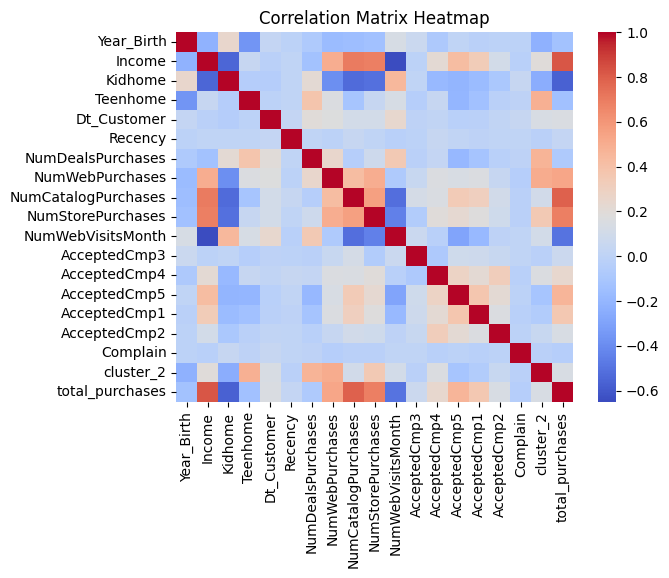

In [ ]:
# Heatmap of correlation
sns.heatmap(correlation_matrix, cmap = 'coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()

Income and Customer Spending by Cluster

This scatter plot allows us to examine the relationship between income and total purchases while also observing how the three customer clusters are distributed. It helps us connect the segmentation results with customer spending behaviour.

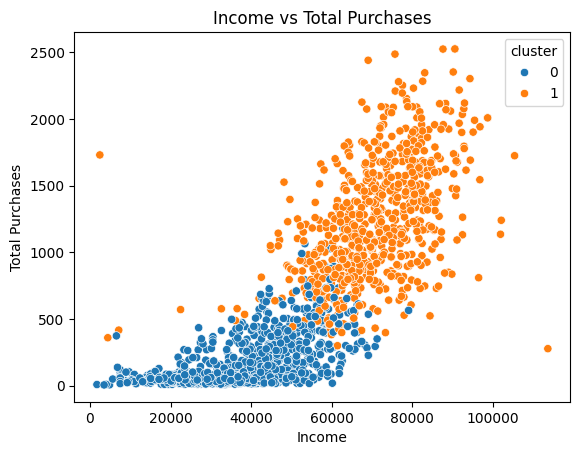

In [ ]:
# Income vs total_purchases with Cluster
sns.scatterplot(data = df_train, x = 'Income', y = 'total_purchases', hue = 'cluster')

# Add labels
plt.title('Income vs Total Purchases')
plt.xlabel('Income')
plt.ylabel('Total Purchases')

plt.show()

Income, Spending and Education

We use education as an additional customer characteristic to examine whether customers with different education categories show different income and spending patterns.

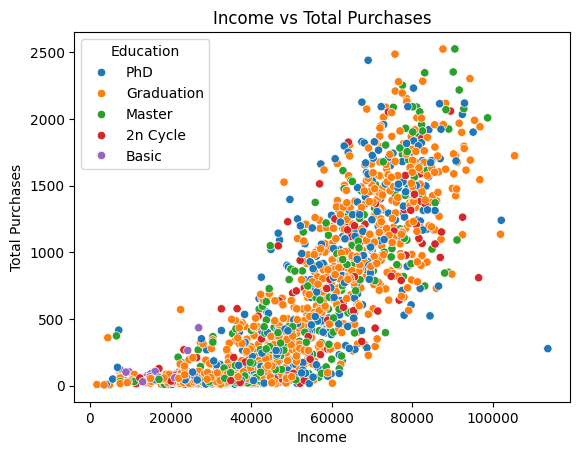

In [ ]:
# Income vs total_purchases with Education
sns.scatterplot(data = df_train, x = 'Income', y = 'total_purchases', hue = 'Education')

# Add labels
plt.title('Income vs Total Purchases')
plt.xlabel('Income')
plt.ylabel('Total Purchases')

plt.show()

Income, Spending and Marital Status

Similarly, we examine whether customer income and total spending patterns differ across marital-status categories. This is exploratory analysis rather than evidence of causality.

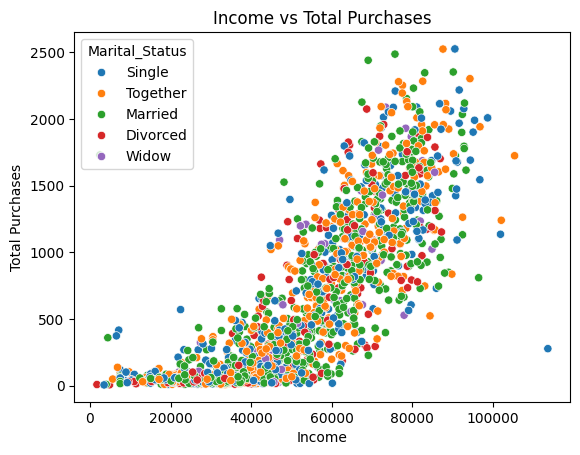

In [ ]:
# Income vs total_purchases with Marital Status
sns.scatterplot(data = df_train, x = 'Income', y = 'total_purchases', hue = 'Marital_Status')

# Add labels
plt.title('Income vs Total Purchases')
plt.xlabel('Income')
plt.ylabel('Total Purchases')

plt.show()

Selecting Variables for the Preliminary Regression Model

Based on the exploratory and correlation analysis, we select Income and cluster membership as predictors for a preliminary regression model of total purchases.

This is intended as a baseline model rather than a complete demand-forecasting model.

In [ ]:
# Update X_train with just cluster and income
X_train = X_train[['Income', 'cluster_1']]
X_test = X_test[['Income', 'cluster_1']]

Linear Regression Model

We use multiple linear regression to estimate the relationship between total purchases and the selected predictors.

Conceptually:

Total Purchases = β₀ + β₁(Income) + β₂(Cluster) + ε

The coefficients indicate the expected change in total purchases associated with a one-unit change in a predictor, holding the other included predictor constant.

In [ ]:
# Prelim model
lm_1 = LinearRegression()
lm_1.fit(X_train, y_train)

LinearRegression()

Interpreting Model Coefficients

We examine the estimated coefficients to understand the direction and magnitude of the relationship between each predictor and total purchases.

For the dummy variable representing a cluster, the coefficient should be interpreted relative to the omitted/reference cluster.

In [ ]:
if hasattr(lm_1, 'feature_names_in_'):
    print("Feature Names:", lm_1.feature_names_in_)
    for feature, coef in zip(lm_1.feature_names_in_, lm_1.coef_):
        print(f"{feature}: {coef}")

Feature Names: ['Income' 'cluster_1']
Income: 0.01708130609219897
cluster_1: 483.3447867940534


Evaluating Model Performance on Training Data

We calculate MSE, RMSE, MAE and R² to evaluate model performance.

MAE: average absolute prediction error.
RMSE: penalises larger errors more heavily.
R²: proportion of variation in total purchases explained by the model.

However, training performance alone can be optimistic, so we also evaluate the model using cross-validation and the test dataset.

In [ ]:
# Model Results
y_pred = lm_1.predict(X_train)

mse = mean_squared_error(y_train, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_train, y_pred)
r2 = r2_score(y_train, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Squared Error (MSE): 96090.85
Root Mean Squared Error (RMSE): 309.99
Mean Absolute Error (MAE): 233.13
R-squared (R2): 0.74


10-Fold Cross-Validation

We use 10-fold cross-validation to assess the stability of model performance. The training data is divided into ten parts, with each part being used once as validation data while the remaining parts are used for training.

The mean R² across the folds provides a more robust estimate of how consistently the model performs on unseen data.

In [ ]:
# Define cross-validation strategy
cv = KFold(n_splits = 10, shuffle = True, random_state = 206)

# Perform cross-validation and get the scores (R-squared by default)
scores = cross_val_score(lm_1, X_train, y_train, cv=cv, scoring='r2')

# 5. Analyze the scores
print("Cross-validation scores:", scores)
print("Mean R-squared:", np.mean(scores))
print("Standard deviation of R-squared:", np.std(scores))

Cross-validation scores: [0.73504423 0.75809277 0.75067023 0.76910807 0.76840461 0.72169201
 0.75208149 0.64778717 0.78794741 0.68505183]
Mean R-squared: 0.7375879811767974
Standard deviation of R-squared: 0.040452800472131054


Finally, we evaluate the model on the 20% test dataset that was not used to train the regression model.

This provides a more realistic indication of how the model may perform on new customers.

In [ ]:
# Model Results
y_pred = lm_1.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Squared Error (MSE): 83687.81
Root Mean Squared Error (RMSE): 289.29
Mean Absolute Error (MAE): 224.29
R-squared (R2): 0.75


Business strategies:

### Customer Segment-Based Retail Strategies

* **High-Income Customers:**
  High-income customers tend to purchase more **meat, wine, and fish**. Supermarkets can strategically place these products across **different sections or shelves** rather than keeping them together. This can encourage customers to move through different parts of the store, increasing their exposure to other products and potentially stimulating additional purchases.

* **Upper-Middle-Income Customers:**
  Upper-middle-income customers consume meat, wine, and fish, but their consumption may not increase significantly. Supermarkets can use **targeted discounts, promotional offers, and loyalty-based incentives** to encourage higher purchase frequency and consumption of these categories.

* **Lower-Middle-Income Customers:**
  Lower-middle-income customers tend to spend less on relatively expensive food items. For this segment, supermarkets can offer **ready-made value bundles** combining essential products such as fruits, vegetables, and other frequently purchased grocery items. Bundling can provide convenience and perceived value while encouraging customers to purchase multiple products together.
